# Project - Bankruptcy Prevention

**Group 1 Members**

Jayshri Kor

Yash Sonone

Karthik Betageri

Jadhav Dattatraya

Marsakatla Vishal

Shraddha Ambre

Saniya Sayyed

### Business Objective 

This is a classification project, since the variable to predict is binary (bankruptcy or non-bankruptcy). The goal here is to model the probability that a business goes bankrupt from different features.


## Exploratory Data Analysis - EDA 

### 1. Import Libraries

In this step, I imported essential Python libraries required for data analysis and visualization. pandas is used for handling and manipulating data, while numpy helps with numerical operations. seaborn and matplotlib are used to create visualizations like graphs and plots. Setting a style improves the readability of visual outputs.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# For better visuals
sns.set_theme(style="whitegrid")

### 2. Load Dataset

Here, I loaded the dataset using read_excel() into a DataFrame. This allows us to work with the dataset in a structured tabular format. Initially, I displayed the first few rows using head() to understand how the data looks. This step revealed that the dataset was not properly formatted.

In [2]:

raw_df = pd.read_excel("bankruptcy-prevention.xlsx")

# Save without index column
raw_df.to_csv("bankruptcy_prevention.csv", index=False )

print("Converted successfully!")

print("Original Data:")
raw_df.head()

Converted successfully!
Original Data:


,industrial_risk; management_risk; financial_flexibility;,credibility;,competitiveness;,operating_risk;,class
0,0.5;1;0;0;0;0.5;bankruptcy,NaN,NaN,NaN,NaN
1,0;1;0;0;0;1;bankruptcy,NaN,NaN,NaN,NaN
2,1;0;0;0;0;1;bankruptcy,NaN,NaN,NaN,NaN
3,0.5;0;0;0.5;0;1;bankruptcy,NaN,NaN,NaN,NaN
4,1;1;0;0;0;1;bankruptcy,NaN,NaN,NaN,NaN


### 3. Fix Dataset Structure

The dataset had all values stored in a single column separated by semicolons. So, I split that column into multiple columns using the str.split() function. Then, I assigned proper column names based on the dataset description. This step converts raw data into a usable structured format.

In [3]:

df = raw_df.iloc[:, 0].str.split(';', expand=True)

df.columns = [
    'industrial_risk',
    'management_risk',
    'financial_flexibility',
    'credibility',
    'competitiveness',
    'operating_risk',
    'class'
]

print("\nAfter Splitting:")
df.head()


After Splitting:


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1,0,0,0,0.5,bankruptcy
1,0,1,0,0,0,1,bankruptcy
2,1,0,0,0,0,1,bankruptcy
3,0.5,0,0,0.5,0,1,bankruptcy
4,1,1,0,0,0,1,bankruptcy


### 4. Data Type Conversion

After splitting, all columns were treated as string (object type). I converted feature columns into numeric (float) type using astype(float). This is important because numerical analysis and machine learning models require numeric inputs. The target column was kept as categorical for now.

In [4]:
for col in df.columns[:-1]:
    df[col] = df[col].astype(float)

print("\nData Types:")
print(df.dtypes)


Data Types:
industrial_risk          float64
management_risk          float64
financial_flexibility    float64
credibility              float64
competitiveness          float64
operating_risk           float64
class                        str
dtype: object


### 5. Basic Data Understanding

In this step, I explored the dataset using functions like shape, info(), and describe(). This helped me understand the number of rows and columns, data types, and statistical summary. It also confirmed that the dataset contains ordinal values like 0, 0.5, and 1.

In [5]:
print("\nShape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Shape: (250, 7)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   industrial_risk        250 non-null    float64
 1   management_risk        250 non-null    float64
 2   financial_flexibility  250 non-null    float64
 3   credibility            250 non-null    float64
 4   competitiveness        250 non-null    float64
 5   operating_risk         250 non-null    float64
 6   class                  250 non-null    str    
dtypes: float64(6), str(1)
memory usage: 16.8 KB
None

Statistical Summary:
       industrial_risk  management_risk  financial_flexibility  credibility  \
count       250.000000       250.000000             250.000000   250.000000   
mean          0.518000         0.614000               0.376000     0.470000   
std           0.411526         0.410705               0.401583     0.415682   
min           0.000000 

### 6. Data Cleaning

Here, I checked for missing values and duplicate rows. The dataset did not contain any actual missing values after fixing the structure. I also checked for duplicates and removed them if present. This ensures that the data is clean and reliable for further analysis.

In [6]:
# ---------------- DATA CLEANING ---------------- #

# Step 1: Basic Info
print("Shape of dataset:", df.shape)
print("\nDataset Info:")
print(df.info())

# Step 2: Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Step 3: Check duplicate rows
duplicates = df.duplicated()
print("\nNumber of duplicate rows:", duplicates.sum())

# Step 4: View duplicate rows
print("\nDuplicate rows:")
print(df[duplicates])

# Step 5: Remove exact duplicates
print("\nBefore removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

# Step 6: Check conflicting duplicates (same features, different class)
feature_duplicates = df.duplicated(subset=df.columns[:-1], keep=False)

print("\nPossible conflicting rows:")
print(df[feature_duplicates].sort_values(by=list(df.columns[:-1])))

# Optional: remove conflicting duplicates if needed
# df = df.drop_duplicates(subset=df.columns[:-1], keep='first')

# Step 7: Final shape
print("\nFinal dataset shape:", df.shape)

# ------------------------------------------------ #

Shape of dataset: (250, 7)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   industrial_risk        250 non-null    float64
 1   management_risk        250 non-null    float64
 2   financial_flexibility  250 non-null    float64
 3   credibility            250 non-null    float64
 4   competitiveness        250 non-null    float64
 5   operating_risk         250 non-null    float64
 6   class                  250 non-null    str    
dtypes: float64(6), str(1)
memory usage: 16.8 KB
None

Missing Values:
industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64

Number of duplicate rows: 147

Duplicate rows:
     industrial_risk  management_risk  financial_flexibility  credibility  \

### 7. Target Variable Analysis

I analyzed the distribution of the target variable (bankruptcy vs non-bankruptcy). Using countplot, I visualized how many companies belong to each class. This step helps identify whether the dataset is balanced or imbalanced, which is important for model performance.

Target Distribution (Count):
class
non-bankruptcy    78
bankruptcy        25
Name: count, dtype: int64

Target Distribution (Percentage):
class
non-bankruptcy    0.757282
bankruptcy        0.242718
Name: proportion, dtype: float64


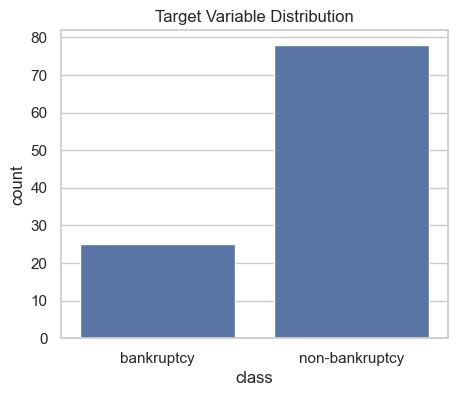

In [7]:
print("Target Distribution (Count):")
print(df['class'].value_counts())

print("\nTarget Distribution (Percentage):")
print(df['class'].value_counts(normalize=True))

plt.figure(figsize=(5,4))
sns.countplot(x='class', data=df)
plt.title("Target Variable Distribution")
plt.show()

### 8. Univariate Analysis

In this step, I analyzed each feature individually. Count plots were used to see the frequency of low, medium, and high values. Histograms helped visualize the distribution pattern. This helps in understanding how each feature behaves independently.

In [8]:
numerical_features = df.select_dtypes(include=['float64', 'int64'])
print(f"\n Numerical Features: {numerical_features}")


 Numerical Features:      industrial_risk  management_risk  financial_flexibility  credibility  \
0                0.5              1.0                    0.0          0.0   
1                0.0              1.0                    0.0          0.0   
2                1.0              0.0                    0.0          0.0   
3                0.5              0.0                    0.0          0.5   
4                1.0              1.0                    0.0          0.0   
..               ...              ...                    ...          ...   
185              0.0              0.5                    0.0          0.5   
187              0.0              0.5                    0.5          0.5   
190              0.0              0.5                    0.5          0.0   
192              0.5              1.0                    0.0          0.0   
194              0.0              1.0                    0.5          0.0   

     competitiveness  operating_risk  
0             

In [9]:
print("\n Skewness Analysis:\n")

for col in numerical_features:
    skew = df[col].skew()
    print(f"{col}: {skew:.4f}", end="")
    if abs(skew) < 0.5:
        print(" (fairly symmetric)")
    elif abs(skew) < 1:
        print(" (moderately skewed)")
    else:
        print(" (highly skewed)")


 Skewness Analysis:

industrial_risk: 0.0536 (fairly symmetric)
management_risk: -0.2402 (fairly symmetric)
financial_flexibility: -0.0179 (fairly symmetric)
credibility: -0.2848 (fairly symmetric)
competitiveness: -0.5670 (moderately skewed)
operating_risk: -0.0573 (fairly symmetric)


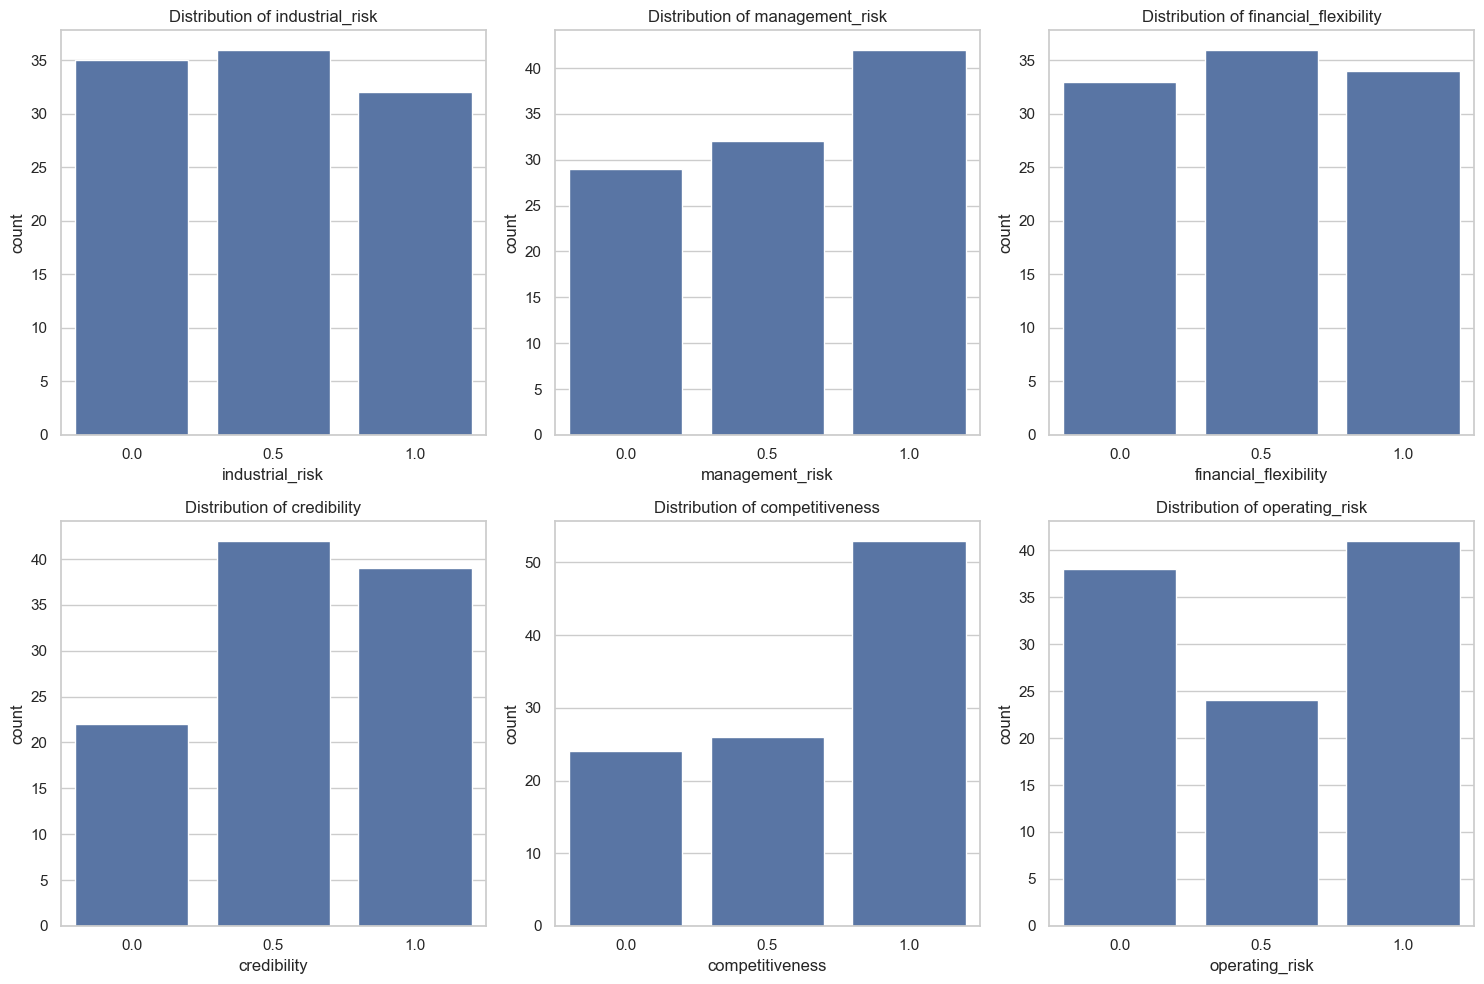

In [10]:
cols = df.columns[:-1]
# numeric distribution

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

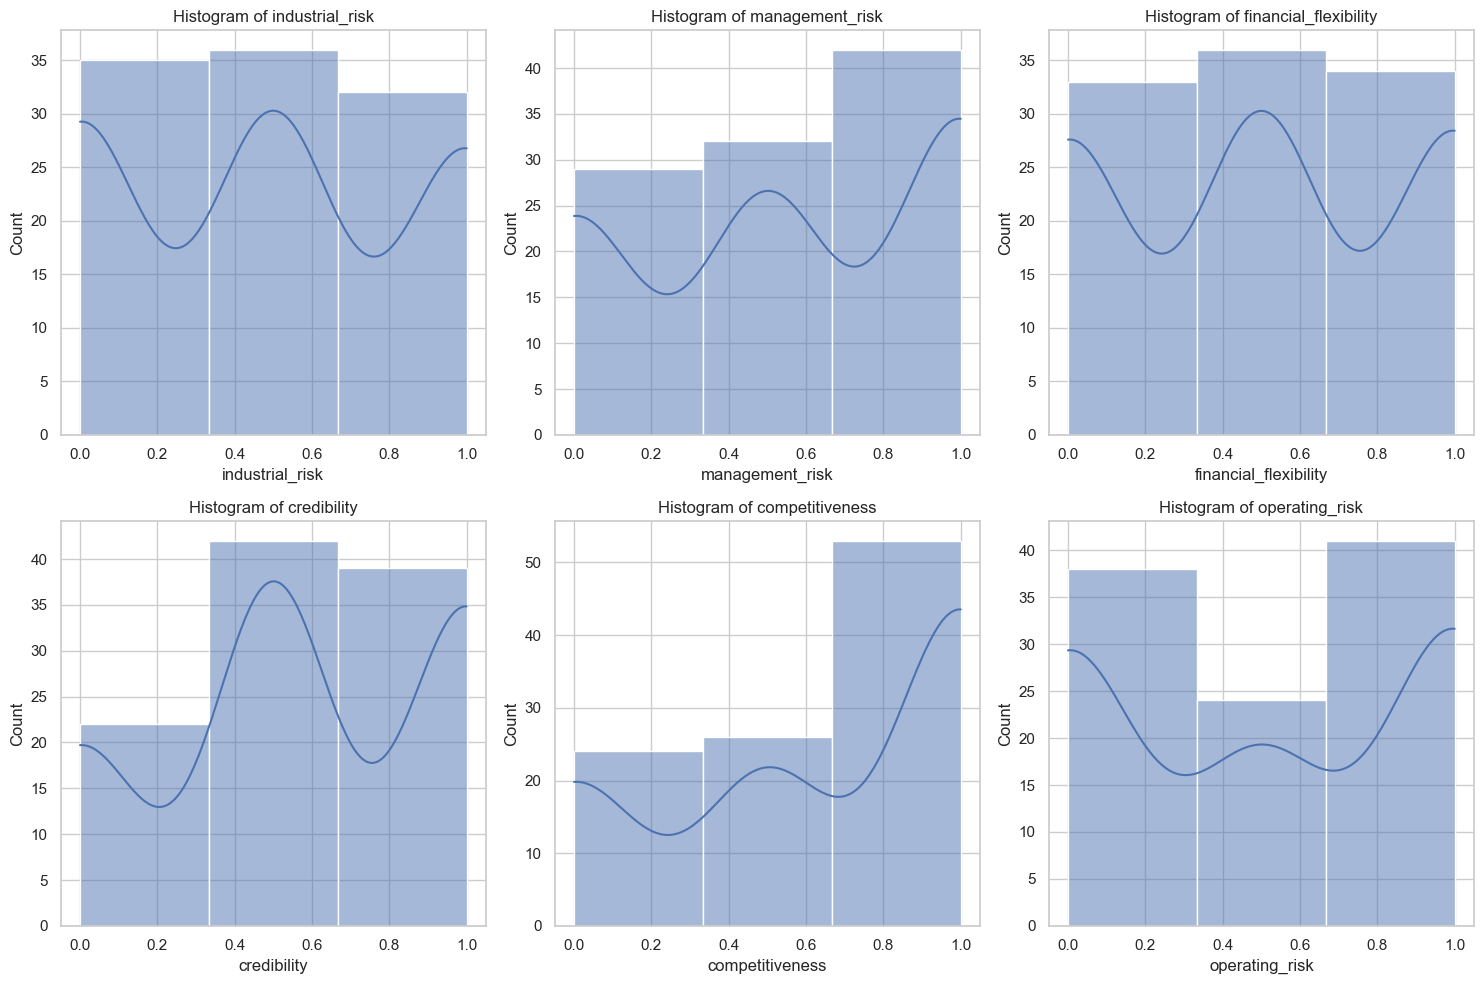

In [11]:
# Histogram (numeric distribution)

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=3, kde=True)
    plt.title(f"Histogram of {col}")
plt.tight_layout()
plt.show()


### 9. Bivariate Analysis

Here, I studied the relationship between each feature and the target variable. Using count plots with hue and boxplots, I compared how feature values differ across bankruptcy classes. This step helps identify which features strongly influence bankruptcy.

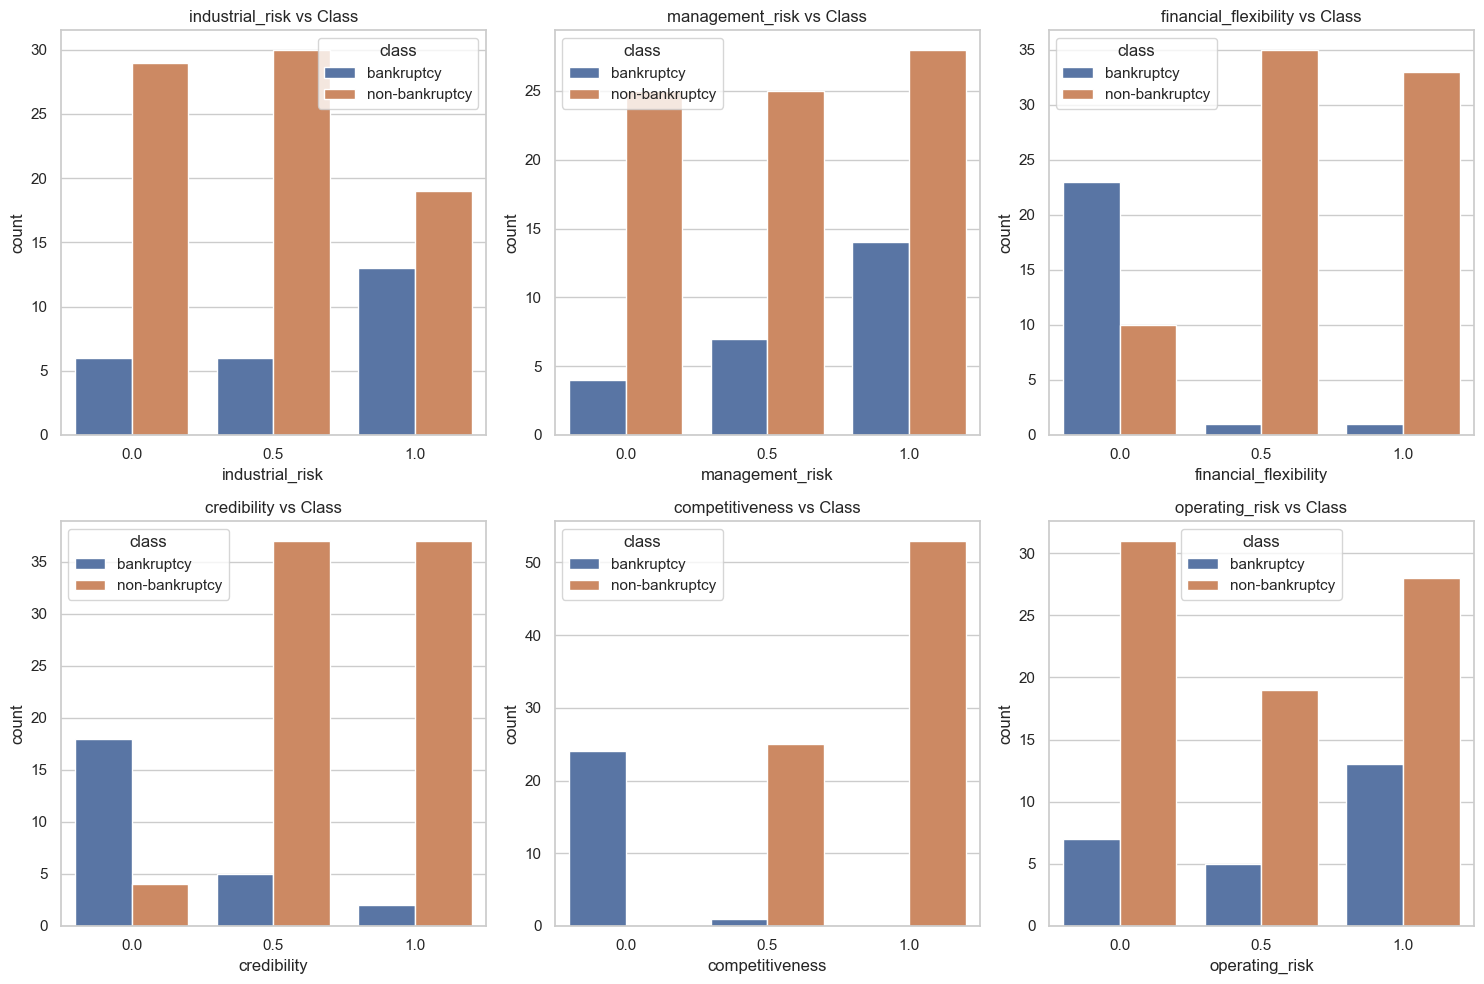

In [12]:
features = ['industrial_risk', 'management_risk', 'financial_flexibility', 
            'credibility', 'competitiveness', 'operating_risk']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=col, hue='class', data=df)
    plt.title(f'{col} vs Class')
plt.tight_layout()
plt.show()


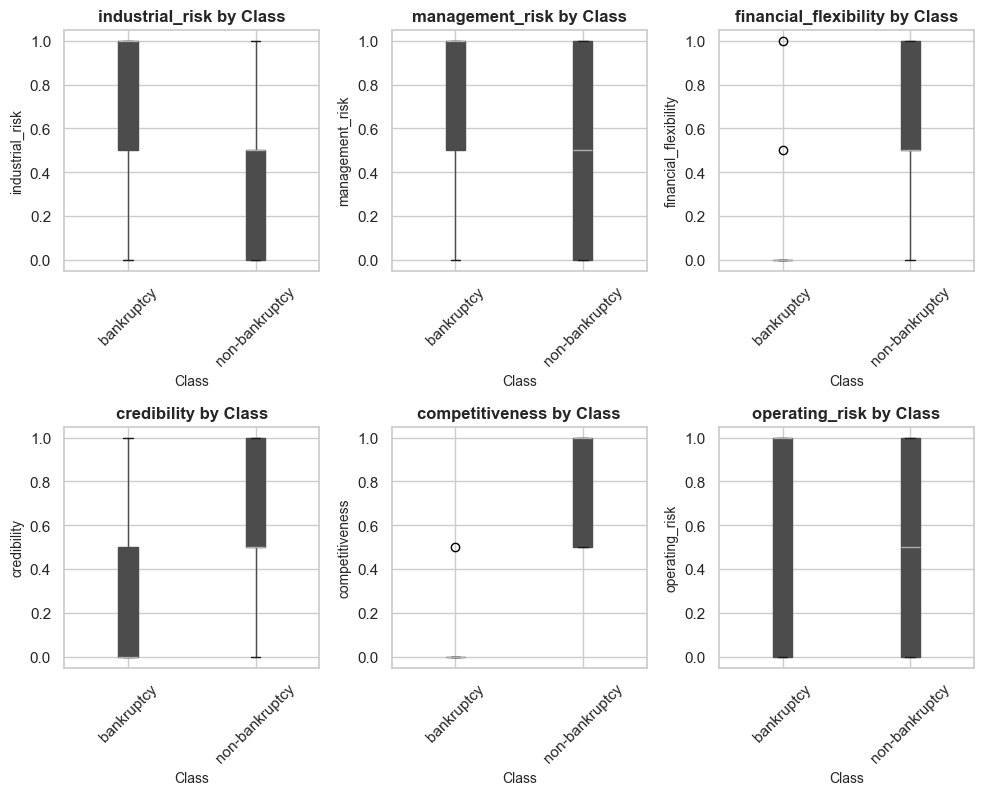

In [13]:
# Boxplots
plt.figure(figsize=(10, 20))
for idx, col in enumerate(numerical_features, start=10):
    #plt.figure(figsize=(10, 20))
    ax = plt.subplot(5, 3, idx )
    df.boxplot(column=col, by='class', ax=ax ,patch_artist=True)
    plt.title(f'{col} by Class', fontsize=12, fontweight='bold')
    plt.xlabel('Class', fontsize=10)
    plt.ylabel(col, fontsize=10)
    plt.suptitle('')  # Remove the automatic title
    plt.xticks(rotation=45)
 
plt.tight_layout()

### Outlier Detection(IQR Method)

In [14]:
print("\n" + "=" * 80)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 80)
 
for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    if len(outliers) > 0:
        print(f"\n{col}:")
        print(f"  Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
        print(f"  Lower bound: {lower_bound:.4f}, Upper bound: {upper_bound:.4f}")
    else:
        print(f"\n{col}: No outliers detected")


OUTLIER DETECTION (IQR Method)

industrial_risk: No outliers detected

management_risk: No outliers detected

financial_flexibility: No outliers detected

credibility: No outliers detected

competitiveness: No outliers detected

operating_risk: No outliers detected


### 10. Multivariate Analysis

I performed correlation analysis using a heatmap to understand relationships between multiple features. Additionally, pairplots were used to visualize interactions between all variables. This helps detect patterns, dependencies, and possible multicollinearity.

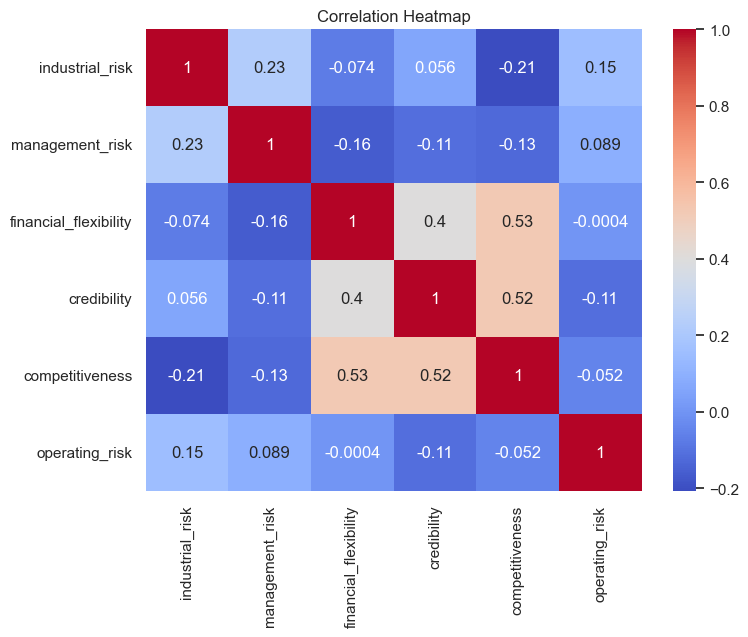

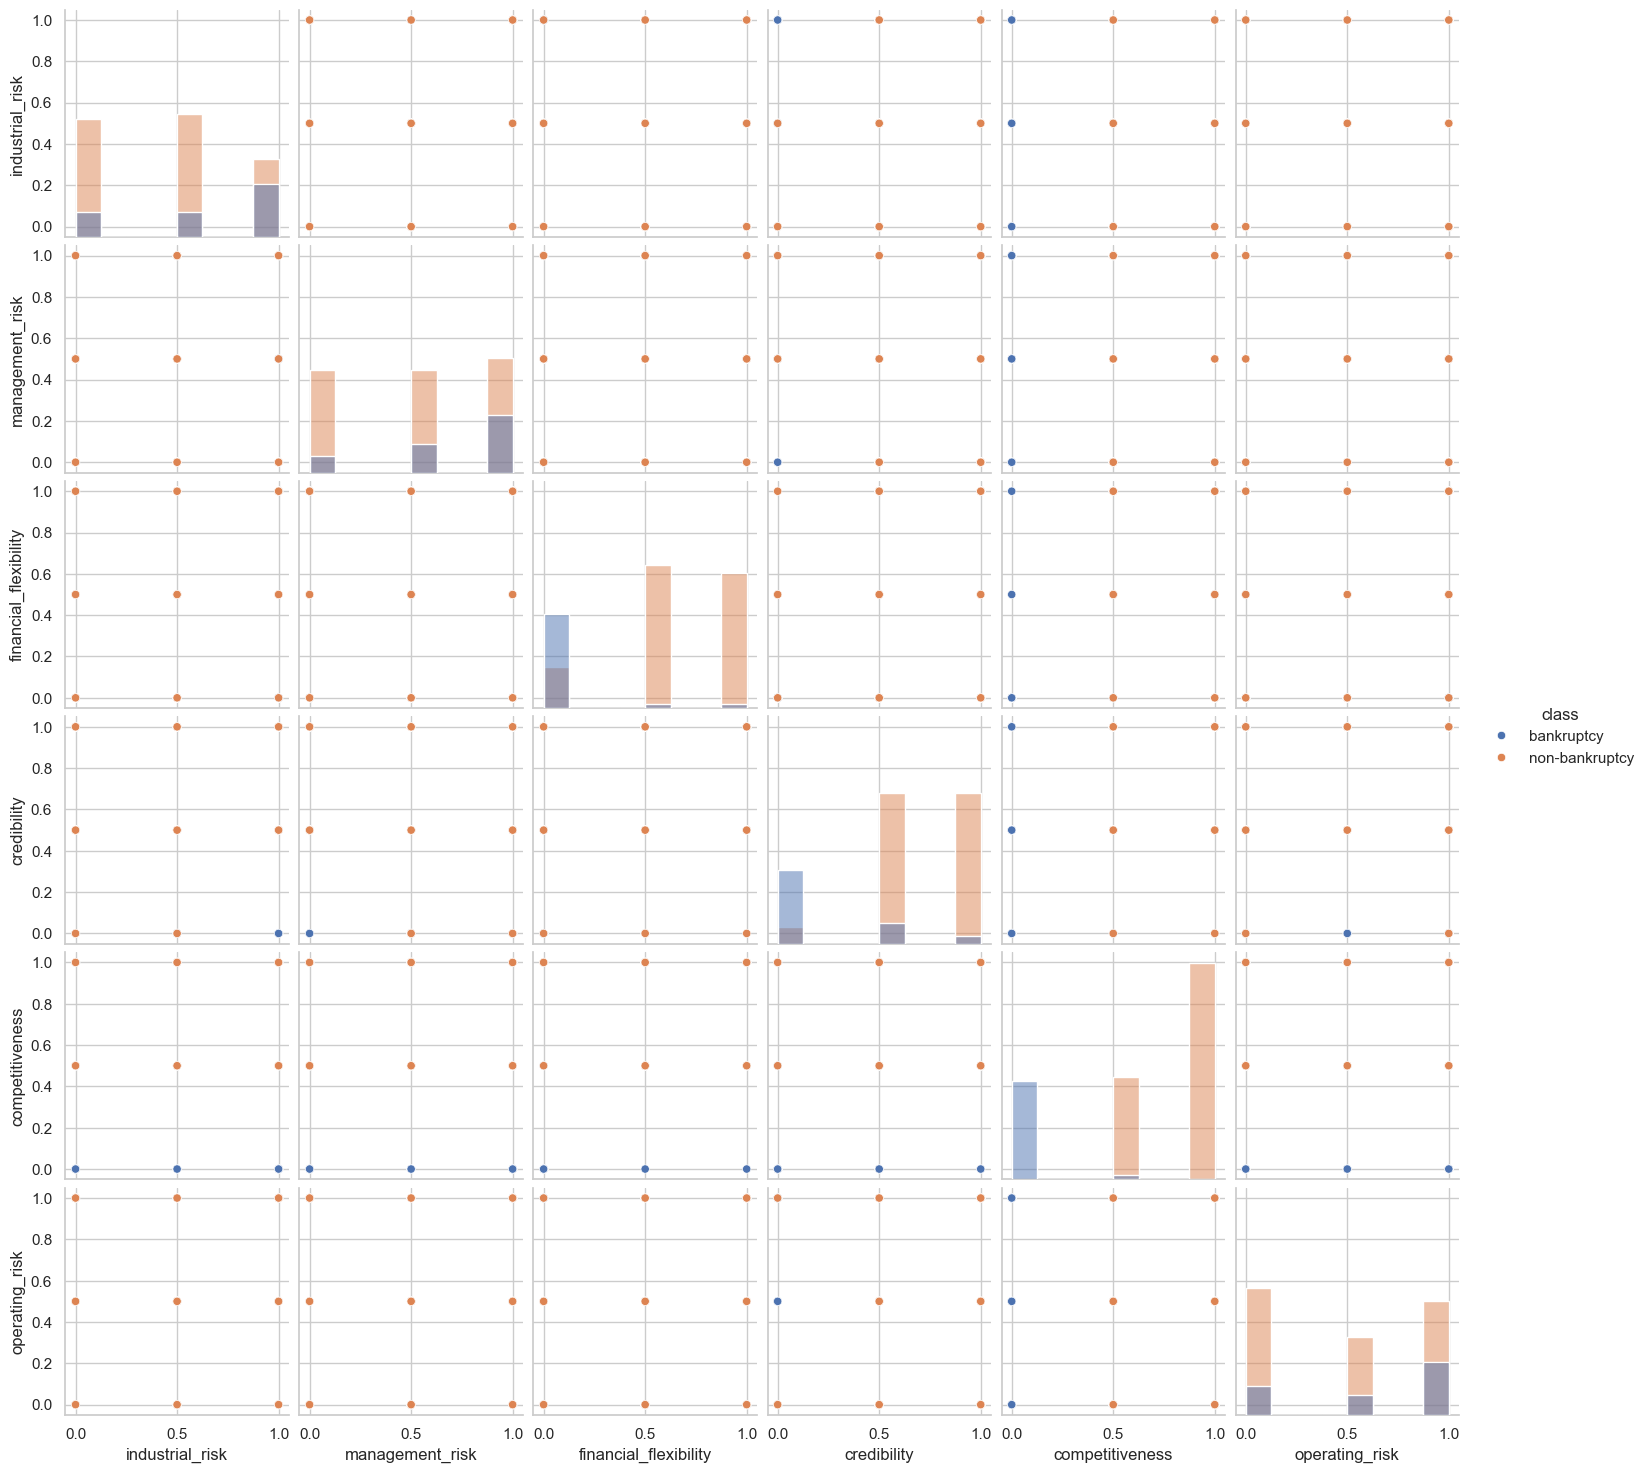

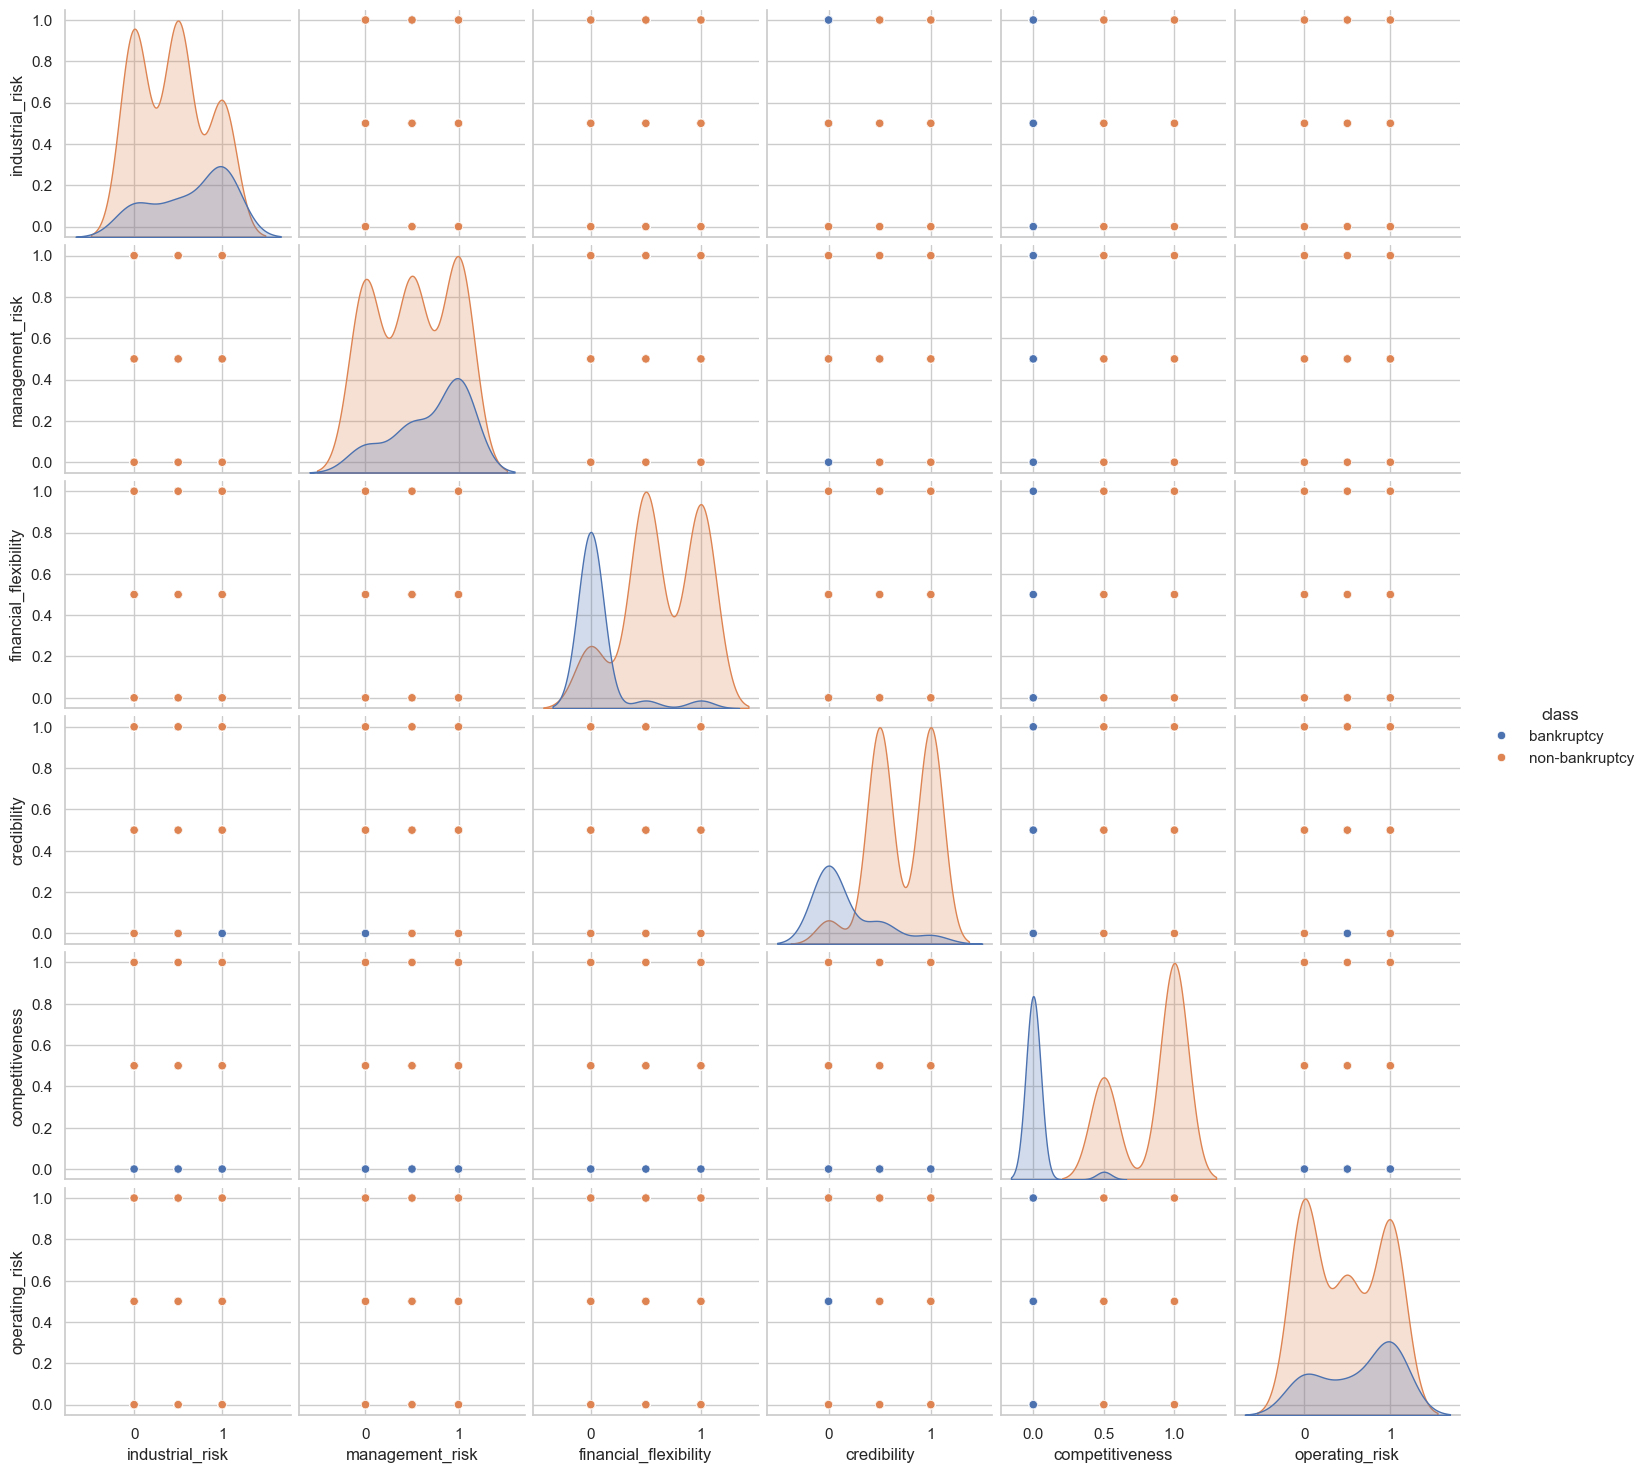

In [15]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
corr = df.drop('class', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Pairplot
sns.pairplot(df, hue='class', diag_kind='hist')
sns.pairplot(df, hue='class')
plt.show()

### 11. Feature Engineering

In [16]:
# Convert target to numeric
df['class'] = df['class'].map({
    'bankruptcy': 1,
    'non-bankruptcy': 0
})

# Create Risk Score (new feature)
df['total_risk_score'] = (
    df['industrial_risk'] +
    df['management_risk'] +
    df['operating_risk']
)

# Create Stability Score
df['stability_score'] = (
    df['financial_flexibility'] +
    df['credibility'] +
    df['competitiveness']
)

print("\nNew Features Added:")
print(df[['total_risk_score', 'stability_score']].head())


New Features Added:
   total_risk_score  stability_score
0               2.0              0.0
1               2.0              0.0
2               2.0              0.0
3               1.5              0.5
4               3.0              0.0


In [17]:
# Save to CSV
df.to_csv("bankruptcy_prevention.csv", index=False )

### 12. Feature Importance

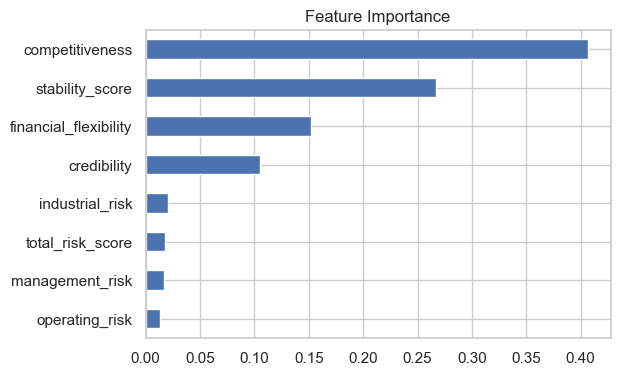

In [18]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('class', axis=1)
y = df['class']

model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(6,4))
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

### 13. Final Dataset Ready

In [19]:
print("\nFinal Dataset:")
print(df.head())

print("\nFinal Shape:", df.shape)


Final Dataset:
   industrial_risk  management_risk  financial_flexibility  credibility  \
0              0.5              1.0                    0.0          0.0   
1              0.0              1.0                    0.0          0.0   
2              1.0              0.0                    0.0          0.0   
3              0.5              0.0                    0.0          0.5   
4              1.0              1.0                    0.0          0.0   

   competitiveness  operating_risk  class  total_risk_score  stability_score  
0              0.0             0.5      1               2.0              0.0  
1              0.0             1.0      1               2.0              0.0  
2              0.0             1.0      1               2.0              0.0  
3              0.0             1.0      1               1.5              0.5  
4              0.0             1.0      1               3.0              0.0  

Final Shape: (103, 9)


## Final Insights

- High industrial and operating risk increases bankruptcy probability
- High credibility and financial flexibility reduce bankruptcy risk
- Dataset is slightly imbalanced but acceptable

## Model Building 

### 1. Import Required Libraries

In [20]:

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, accuracy_score

from sklearn.inspection import permutation_importance

import pandas as pd

### 2. Split Features & Target

In [21]:
X = df.drop("class", axis=1)
y = df["class"]

### 3. Train-Test Split

In [22]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (82, 8)
Test shape: (21, 8)


### 4. CV Setup

In [23]:
# CV Setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 5. Defining models + Pipelines

In [24]:
# Define Models + Pipelines

models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True))
    ]),
    
    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),
    
    "Random Forest": Pipeline([
        ('model', RandomForestClassifier())
    ]),
    
    "Gradient Boosting": Pipeline([
        ('model', GradientBoostingClassifier())
    ]),
    
    "AdaBoost": Pipeline([
        ('model', AdaBoostClassifier())
    ])
}


### 6. Hyperparameter Tuning

In [25]:
# Hyperparameter Grids

param_grids = {
    "Logistic Regression": {
        'model__C': [0.1, 1, 10]
    },
    
    "SVM": {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf']
    },
    
    "KNN": {
        'model__n_neighbors': [3, 5, 7]
    },
    
    "Random Forest": {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 5, 10]
    },
    
    "Gradient Boosting": {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1]
    },
    
    "AdaBoost": {
        'model__n_estimators': [50, 100],
        'model__learning_rate': [0.5, 1]
    }
}

### 7. Final Comparison of Tuned Models

In [47]:
results = []
trained_models = {}   # 🔥 store models here

for name in models:
    
    grid = GridSearchCV(
        models[name],
        param_grids[name],
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    trained_models[name] = best_model   # ✅ store model
    
    # evaluation
    y_pred = best_model.predict(X_test)
    
    if hasattr(best_model, "predict_proba"):
        y_prob = best_model.predict_proba(X_test)[:, 1]
    else:
        y_prob = best_model.decision_function(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

In [48]:
# Results Comparison
# =========================================
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)

print("\n===== Model Comparison =====")
results_df


===== Model Comparison =====


,Model,Accuracy,ROC-AUC
3,Random Forest,0.952381,1.0000
0,Logistic Regression,0.952381,0.9875
1,SVM,0.904762,0.9875
2,KNN,0.952381,0.9000
4,Gradient Boosting,0.952381,0.9000
5,AdaBoost,0.952381,0.9000


### Interpret feature importance

100%|█████████████████████████████████████████████████████████████████████████████████| 21/21 [00:00<00:00, 142.49it/s]


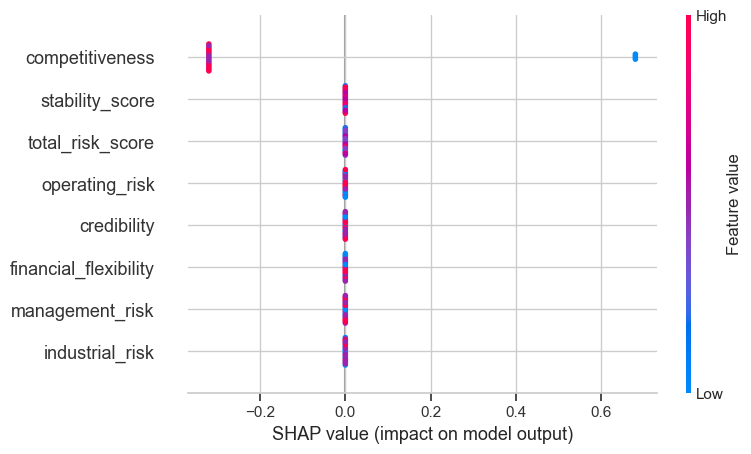

In [36]:
import shap

model = best_model.named_steps['model']

# Use small sample for speed
X_sample = X_train[:50]

explainer = shap.KernelExplainer(model.predict, X_sample)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

### ROC Curve (Visual Performance)

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### 10. Select Best Model

In [50]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Random Forest


In [52]:
best_model = trained_models[best_model_name]
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If 

### Cross validation

In [54]:

import numpy as np

# ROC-AUC scores
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring='roc_auc')

print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-Validation Scores: [1. 1. 1. 1. 1.]
Mean CV Score: 1.0
Standard Deviation: 0.0


In [ ]:
### Chacking Overfitting and Probability

In [56]:
# Train predictions
y_train_pred = best_model.predict(X_train)

# Test predictions
y_test_pred = best_model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Difference
gap = train_acc - test_acc
print("Overfitting Gap:", gap)

Train Accuracy: 1.0
Test Accuracy: 0.9523809523809523
Overfitting Gap: 0.04761904761904767


In [57]:
# Train probabilities
y_train_prob = best_model.predict_proba(X_train)[:, 1]
y_test_prob = best_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("Train ROC-AUC:", train_auc)
print("Test ROC-AUC:", test_auc)
print("AUC Gap:", train_auc - test_auc)

Train ROC-AUC: 1.0
Test ROC-AUC: 1.0
AUC Gap: 0.0


In [58]:
if cv_scores.std() < 0.05 and (train_acc - test_acc) < 0.05:
    print("✅ Model is stable and not overfitting")
else:
    print("⚠️ Model may be unstable or overfitting")

✅ Model is stable and not overfitting


### Downloading the pickle file

In [60]:
import joblib

joblib.dump(best_model, "bankruptcy_model.pkl")

['bankruptcy_model.pkl']

## Final Insights

After completing the model building process, it was observed that simpler models like SVM and KNN performed better compared to more complex models. This is mainly because the dataset is relatively small and clean, which suits these algorithms well. The use of cross-validation helped in getting a more reliable estimate of model performance and ensured that the results were not dependent on a single train-test split. Hyperparameter tuning further improved the performance of the selected models. Overall, the final model is able to make reasonably accurate predictions without overfitting, making it suitable for this dataset.